## ------------------------------------------------------------ ###
## Set up environment
## ------------------------------------------------------------ ###

In [2]:
import glob
import os
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
import xarray as xr
import matplotlib.pyplot as plt
from rasterio.warp import Resampling, reproject
from rasterio.features import geometry_mask
from rasterio.enums import Resampling
from rasterio.mask import mask
from rasterio.plot import plotting_extent
from shapely import box

# --------------------------
# Configuration — edit these
# --------------------------
DEM_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/dem/"
NETCDF_DIR = "/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/"
event_details_fp = 'EventDetails'

from functions import filter_closer_to_catchment_xr_bounds
from helper_functions import extract_ha_num, find_matching_netcdf

from config import  CATCHMENTS

In [3]:
def proportion_waterbodies(fine_array, dem_info, coarse_da):
    coarse_shape = np.squeeze(coarse_da.values).shape
    coarse_array = np.full(coarse_shape, np.nan, dtype=np.float32)

    fine = fine_array.astype(np.float32).copy()

    reproject(source=fine,destination=coarse_array,src_transform=dem_info["transform"],src_crs=dem_info["crs"],
              dst_transform=coarse_da.rio.transform(),dst_crs=coarse_da.rio.crs,src_nodata=np.nan,dst_nodata=np.nan,
              resampling=Resampling.average)

    return coarse_array

def proportion_urban(fine_array, dem_info, coarse_da):
    coarse_shape = np.squeeze(coarse_da.values).shape
    coarse_array = np.full(coarse_shape, np.nan, dtype=np.float32)

    # 1 = urban/sub-urban, 0 = everything else
    urban = np.isin(fine_array, [20, 21]).astype(np.float32)

    # Preserve NaNs outside the catchment
    urban[np.isnan(fine_array)] = np.nan

    reproject(source=urban,destination=coarse_array,src_transform=dem_info["transform"],src_crs=dem_info["crs"],
              dst_transform=coarse_da.rio.transform(),dst_crs=coarse_da.rio.crs,src_nodata=np.nan,dst_nodata=np.nan,
              resampling=Resampling.average)

    return coarse_array


# Function to calculate proportion of each 5 km cell inside the catchment
def proportion_inside_catchment(inside_mask, src_transform, src_crs, coarse_da):
    coarse_shape = np.squeeze(coarse_da.values).shape

    # Count of 30 m cells inside each 5 km cell
    inside_count = np.full(coarse_shape, np.nan, dtype=np.float32)

    # Count of all 30 m cells contributing to each 5 km cell
    total_count = np.full(coarse_shape, np.nan, dtype=np.float32)

    # Reproject inside/outside mask
    reproject(source=inside_mask,destination=inside_count,src_transform=src_transform,src_crs=src_crs,
              dst_transform=coarse_da.rio.transform(),dst_crs=coarse_da.rio.crs,src_nodata=None,dst_nodata=np.nan,
              resampling=Resampling.sum)

    # Create an array of ones to count all contributing 30 m cells
    all_cells = np.ones_like(inside_mask, dtype=np.float32)

    reproject(source=all_cells,destination=total_count,src_transform=src_transform,src_crs=src_crs,
              dst_transform=coarse_da.rio.transform(),dst_crs=coarse_da.rio.crs,src_nodata=None,dst_nodata=np.nan,
              resampling=Resampling.sum)

    # Proportion inside catchment
    proportion = inside_count / total_count * 100

    # Completely outside catchment = 0 inside cells → NaN
    proportion[inside_count == 0] = np.nan

    return proportion

## ------------------------------------------------------------ ###
## Get dataset containing events from across all catchments
## ------------------------------------------------------------ ###

In [4]:
fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/all_catchments_added_soilvars.pkl"
rainfall_events_all_df = pd.read_pickle(fp)

## ------------------------------------------------------------ ###
## Loop through all catchments
## ------------------------------------------------------------ ###

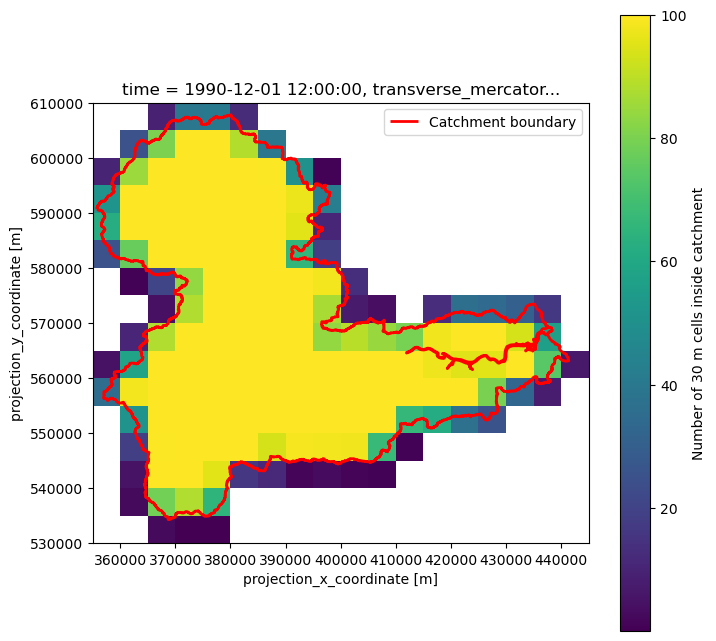

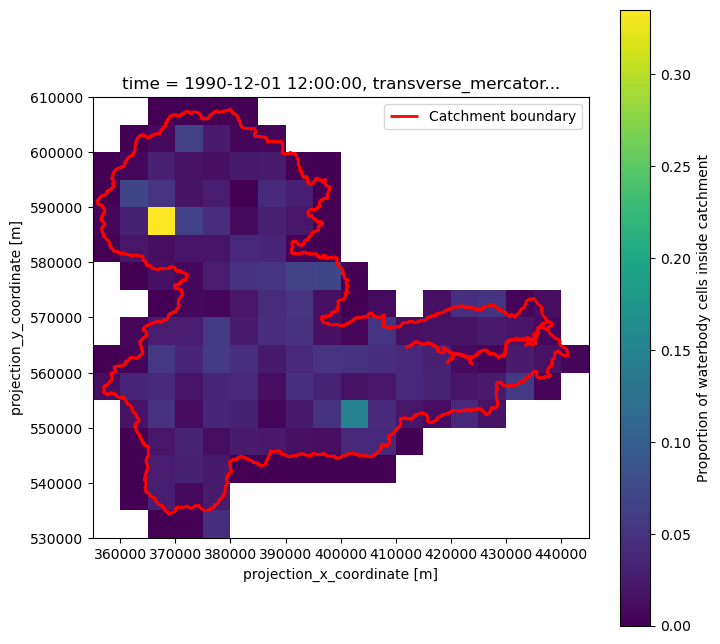

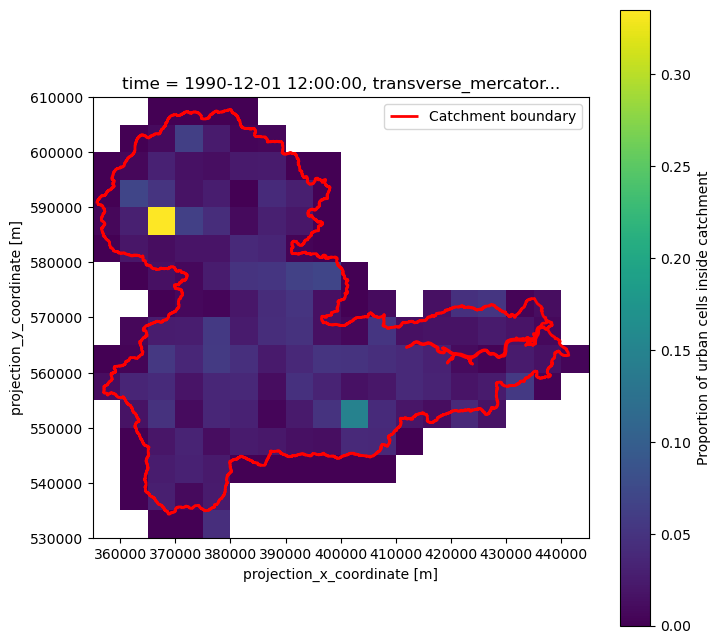

In [5]:
TARGET_HA='23'

# ------------------------------------------------------
# Get catchment boundary
# ------------------------------------------------------
boundary_gdf    = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(TARGET_HA)]
CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

# ------------------------------------------------------
# Get DEM files (for metadata to use in aggregation)
# ------------------------------------------------------
dem_files = [p for p in glob.glob(os.path.join(DEM_DIR, "*.tif"))
    if extract_ha_num(p) in [TARGET_HA]]
if not dem_files:
    raise FileNotFoundError(f"No DEM found for HA_NUM {TARGET_HA} in {DEM_DIR}")

dem_path = dem_files[0]
# ha_num = extract_ha_num(dem_path)

with rasterio.open(dem_path) as dem:
    dem_info = {"bounds": box(*dem.bounds),"transform": dem.transform,"crs": dem.crs,"width": dem.width,
                "height": dem.height,"mask": dem.read(1), }

# ------------------------------------------------------
# Get 5 km soil moisture data (for using to define 5km grid to aggregate to) 
# ------------------------------------------------------    
soil_moisture_5km_fp = find_matching_netcdf(os.path.join(NETCDF_DIR, 'Ens_01'), 1991, 1,1 )
with xr.open_dataset(soil_moisture_5km_fp) as soil_moisture_5km:
    grav_clipped = filter_closer_to_catchment_xr_bounds(
            soil_moisture_5km.isel(time=0), CATCHMENT_POLY)["moisture_content_of_soil_layer"]
    grav_clipped = grav_clipped.rio.write_crs("EPSG:27700")    
    
    
# ------------------------------------------------------
# Get waterbodies data and aggregate to 5km (proportion of cells which are water)
# ------------------------------------------------------    
waterbodies_path = f'/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/associate_layers/waterbodies/waterbodies_{TARGET_HA}.tif'
with rasterio.open(waterbodies_path) as src:
    waterbodies_data = src.read(1)
    valid = waterbodies_data != src.nodata
    waterbodies_data[~valid] = np.nan
    
waterbodies_5km = proportion_waterbodies(waterbodies_data, dem_info, grav_clipped)

# ------------------------------------------------------
# Get landcover data and aggregate to 5km (proportion of cells which are urban/semi-urban)
# ------------------------------------------------------     
landcover_path = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/CEH_landcover/resampled_30m/landcover_resampled_30m_nearest.tif"
with rasterio.open(landcover_path) as src:
    landcover_data, landcover_transform = mask(src,[CATCHMENT_POLY],crop=True,nodata=0)

landcover_data = landcover_data.astype(float)
landcover_data[landcover_data == 0] = np.nan
landcover_data = landcover_data[0]

urban_5km = proportion_urban(landcover_data, dem_info, grav_clipped)  

# ------------------------------------------------------
# Find the proportion of 30m cells outside the catchment boundary within each 5km cell
# ------------------------------------------------------ 
# Create a 30 m mask: 1 = inside catchment, 0 = outside
with rasterio.open(landcover_path) as src:
    inside_mask = geometry_mask([CATCHMENT_POLY],out_shape=(src.height, src.width),transform=src.transform,invert=True)

inside_mask = inside_mask.astype(np.float32)
inside_proportion_5km = proportion_inside_catchment(inside_mask,src.transform,src.crs,grav_clipped)
inside_da = grav_clipped.copy(data=inside_proportion_5km)

fig, ax = plt.subplots(figsize=(8, 8))
inside_da.plot(ax=ax, cmap="viridis",
               cbar_kwargs={"label": "Number of 30 m cells inside catchment"})
boundary_gdf.boundary.plot(ax=ax, edgecolor="red", linewidth=2, label="Catchment boundary")
ax.set_aspect("equal")
ax.legend()
plt.show()



waterbodies_5km_da = grav_clipped.copy(data=waterbodies_5km)
fig, ax = plt.subplots(figsize=(8, 8))
waterbodies_5km_da.plot(ax=ax, cmap="viridis",
               cbar_kwargs={"label": "Proportion of waterbody cells inside catchment"})
boundary_gdf.boundary.plot(ax=ax, edgecolor="red", linewidth=2, label="Catchment boundary")
ax.set_aspect("equal")
ax.legend()
plt.show()

urban_5km_da = grav_clipped.copy(data=waterbodies_5km)

fig, ax = plt.subplots(figsize=(8, 8))
urban_5km_da.plot(ax=ax, cmap="viridis",
               cbar_kwargs={"label": "Proportion of urban cells inside catchment"})
boundary_gdf.boundary.plot(ax=ax, edgecolor="red", linewidth=2, label="Catchment boundary")
ax.set_aspect("equal")
ax.legend()
plt.show()


# this_catchment = rainfall_events_all_df[rainfall_events_all_df['catchment_num']==TARGET_HA].copy()
# water_props = []
# for i, row in this_catchment.iterrows():
#     water_props.append(waterbodies_5km[row["y_idx"], row["x_idx"]])
# this_catchment['water_prop'] = water_props
# print(TARGET_HA, np.nanmax(this_catchment['water_prop']))

# all_catchments_dict[TARGET_HA] = this_catchment


In [8]:
all_catchments_dict = {}

for number, TARGET_HA in enumerate(CATCHMENTS['HA_NUM']):

    # ------------------------------------------------------
    # Get catchment boundary
    # ------------------------------------------------------
    boundary_gdf    = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(TARGET_HA)]
    CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

    # ------------------------------------------------------
    # Get DEM files (for metadata to use in aggregation)
    # ------------------------------------------------------
    dem_files = [p for p in glob.glob(os.path.join(DEM_DIR, "*.tif"))
        if extract_ha_num(p) in [TARGET_HA]]
    if not dem_files:
        raise FileNotFoundError(f"No DEM found for HA_NUM {TARGET_HA} in {DEM_DIR}")

    dem_path = dem_files[0]
    # ha_num = extract_ha_num(dem_path)

    with rasterio.open(dem_path) as dem:
        dem_info = {"bounds": box(*dem.bounds),"transform": dem.transform,"crs": dem.crs,"width": dem.width,
                    "height": dem.height,"mask": dem.read(1), }

    # ------------------------------------------------------
    # Get 5 km soil moisture data (for using to define 5km grid to aggregate to) 
    # ------------------------------------------------------    
    soil_moisture_5km_fp = find_matching_netcdf(os.path.join(NETCDF_DIR, 'Ens_01'), 1991, 1,1 )
    with xr.open_dataset(soil_moisture_5km_fp) as soil_moisture_5km:
        grav_clipped = filter_closer_to_catchment_xr_bounds(
                soil_moisture_5km.isel(time=0), CATCHMENT_POLY)["moisture_content_of_soil_layer"]
        grav_clipped = grav_clipped.rio.write_crs("EPSG:27700")    


    # ------------------------------------------------------
    # Get waterbodies data and aggregate to 5km (proportion of cells which are water)
    # ------------------------------------------------------    
    waterbodies_path = f'/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/associate_layers/waterbodies/waterbodies_{TARGET_HA}.tif'
    with rasterio.open(waterbodies_path) as src:
        waterbodies_data = src.read(1)
        valid = waterbodies_data != src.nodata
        waterbodies_data[~valid] = np.nan

    waterbodies_5km = proportion_waterbodies(waterbodies_data, dem_info, grav_clipped)

    # ------------------------------------------------------
    # Get landcover data and aggregate to 5km (proportion of cells which are urban/semi-urban)
    # ------------------------------------------------------     
    landcover_path = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/CEH_landcover/resampled_30m/landcover_resampled_30m_nearest.tif"
    with rasterio.open(landcover_path) as src:
        landcover_data, landcover_transform = mask(src,[CATCHMENT_POLY],crop=True,nodata=0)

    landcover_data = landcover_data.astype(float)
    landcover_data[landcover_data == 0] = np.nan
    landcover_data = landcover_data[0]

    urban_5km = proportion_urban(landcover_data, dem_info, grav_clipped)  

    # ------------------------------------------------------
    # Find the proportion of 30m cells outside the catchment boundary within each 5km cell
    # ------------------------------------------------------ 
    # Create a 30 m mask: 1 = inside catchment, 0 = outside
    with rasterio.open(landcover_path) as src:
        inside_mask = geometry_mask([CATCHMENT_POLY],out_shape=(src.height, src.width),transform=src.transform,invert=True)

    inside_mask = inside_mask.astype(np.float32)
    inside_proportion_5km = proportion_inside_catchment(inside_mask,src.transform,src.crs,grav_clipped)

    this_catchment = rainfall_events_all_df[rainfall_events_all_df['catchment_num']==TARGET_HA].copy()
    
    # Set up lists to store results for each event in this catchment
    water_props = []
    urban_props = []
    inside_props = []
    
    # Loop through each row for catchment
    for i, row in this_catchment.iterrows():
        water_props.append(waterbodies_5km[row["y_idx"], row["x_idx"]])
        urban_props.append(urban_5km[row["y_idx"], row["x_idx"]])
        inside_props.append(inside_proportion_5km[row["y_idx"], row["x_idx"]])
        
    # Add values back in as columns
    this_catchment['water_prop'] = water_props
    this_catchment['urban_prop'] = urban_props
    this_catchment['inside_prop'] = inside_props
    
    print(number, TARGET_HA, np.nanmax(this_catchment['water_prop']))

    all_catchments_dict[TARGET_HA] = this_catchment
    
out = pd.concat(all_catchments_dict.values(), ignore_index=True)
out    

0 49 0.081324
1 50 0.065688
2 51 0.04603842
3 52 0.46785957
4 53 0.135312
5 55 0.089998126
6 56 0.4835986
7 57 0.14580286
8 58 0.103579774
9 59 0.079152
10 60 0.112150095
11 61 0.05076
12 62 0.0799171
13 63 0.09155428
14 64 0.12963684
15 65 0.19560005
16 66 0.09070826
17 67 0.16133335
18 68 0.18574241
19 69 0.11038972
20 70 0.12578353
21 71 0.083264
22 72 0.116052
23 73 0.289644
24 74 0.13704889
25 75 0.217608
26 76 0.15096
27 77 0.090768
28 78 0.10248
29 79 0.098856
30 80 0.17195243
31 81 0.07399678
32 82 0.244716
33 83 0.06639892
34 84 0.17217496
35 85 0.689268
36 86 0.107664
37 87 0.10233325
38 1 0.064881176
39 2 0.164876
40 3 0.34122
41 4 0.184012
42 5 0.21745549
43 6 0.44646
44 7 0.103144
45 8 0.130884
46 9 0.042012
47 10 0.12037432
48 11 0.043392
49 12 0.12847783
50 13 0.059952
51 14 0.061296
52 15 0.334872
53 16 0.232752
54 17 0.353424
55 18 0.20698291
56 19 0.08658718
57 20 0.045888
58 21 0.104436
59 22 0.067656
60 23 0.335256
61 24 0.060312
62 25 0.12770875
63 26 0.16359656
64

,max_precip,t_global,t_local,x_idx,y_idx,x_idx_global,y_idx_global,x_coord,y_coord,ens,...,lu_at_peak,hc_at_peak.1,peak_cell_slope_avg,peak_cell_slope_max,catchment_slope_avg,catchment_slope_max,peak_cell_sink_frac,water_prop,urban_prop,inside_prop
0,33.823380,4922,24,11,3,67,11,137500.0,22500.0,1,...,0.048631,0.600732,NaN,NaN,NaN,NaN,NaN,0.021324,0.036999,54.422005
1,93.955116,5897,7,27,18,83,26,217500.0,97500.0,1,...,0.036350,0.330241,NaN,NaN,NaN,NaN,NaN,0.033366,0.029847,87.087601
2,32.004837,4836,46,26,16,82,24,212500.0,87500.0,1,...,0.038800,0.380427,NaN,NaN,NaN,NaN,NaN,0.011512,0.018142,88.767998
3,57.549026,6110,10,17,6,73,14,167500.0,37500.0,1,...,0.034814,0.322188,NaN,NaN,NaN,NaN,NaN,0.015873,0.128260,62.273605
4,32.734352,4774,9,17,7,73,15,167500.0,42500.0,1,...,0.028875,0.253981,NaN,NaN,NaN,NaN,NaN,0.020076,0.334944,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105584,35.923145,5175,22,8,6,118,48,392500.0,207500.0,15,...,0.020267,0.103449,NaN,NaN,NaN,NaN,NaN,0.008820,0.033072,100.000000
105585,47.853752,6812,2,4,11,114,53,372500.0,232500.0,15,...,0.019731,0.097438,NaN,NaN,NaN,NaN,NaN,0.029844,0.046392,100.000000
105586,36.347977,5650,1,7,4,117,46,387500.0,197500.0,15,...,0.020276,0.107064,NaN,NaN,NaN,NaN,NaN,0.028684,0.055757,71.051201
105587,30.292673,7799,8,5,7,115,49,377500.0,212500.0,15,...,0.019551,0.095549,NaN,NaN,NaN,NaN,NaN,0.066281,0.068747,94.345596


In [19]:
out = pd.read_pickle(f"/scratch/hydro4/users/kv25483/FutureFlood/Data/{event_details_fp}/all_catchments_added_soilvars_and_othervars.pkl")

In [11]:
out.to_pickle(f"/scratch/hydro4/users/kv25483/FutureFlood/Data/{event_details_fp}/all_catchments_added_soilvars_and_othervars.pkl")

In [33]:
# out.sort_values (by='water_prop', ascending=False)[:50]
out[out['water_prop']>0.50]

# len(out[out['water_prop']>0.50]) / 105589 * 100

,max_precip,t_global,t_local,x_idx,y_idx,x_idx_global,y_idx_global,x_coord,y_coord,ens,...,lu_at_peak,hc_at_peak.1,peak_cell_slope_avg,peak_cell_slope_max,catchment_slope_avg,catchment_slope_max,peak_cell_sink_frac,water_prop,urban_prop,inside_prop
29836,39.424751,5848,4,3,3,87,144,237500.0,687500.0,4,...,0.058519,0.897223,2.134962,33.458782,10.126401,58.221699,0.006813,0.689268,0.006696,100.000000
29863,31.622889,6767,14,3,3,87,144,237500.0,687500.0,4,...,0.058519,0.897223,2.134962,33.458782,10.126401,58.221699,0.006813,0.689268,0.006696,100.000000
29888,32.043777,5295,3,3,3,87,144,237500.0,687500.0,5,...,0.058519,0.897223,2.134962,33.458782,10.126401,58.221699,0.006813,0.689268,0.006696,100.000000
29898,31.853838,6086,11,3,3,87,144,237500.0,687500.0,5,...,0.058519,0.897223,2.134962,33.458782,10.126401,58.221699,0.006813,0.689268,0.006696,100.000000
29905,33.304253,6012,3,3,4,87,145,237500.0,692500.0,5,...,0.061043,0.968590,4.736609,44.424450,10.126401,58.221699,0.010040,0.668568,0.011004,100.000000
29939,33.932453,6179,6,3,4,87,145,237500.0,692500.0,6,...,0.061043,0.968590,4.736609,44.424450,10.126401,58.221699,0.010040,0.668568,0.011004,100.000000
29983,31.323521,5503,15,3,4,87,145,237500.0,692500.0,8,...,0.061043,0.968590,4.736609,44.424450,10.126401,58.221699,0.010040,0.668568,0.011004,100.000000
29997,39.221100,5155,2,3,3,87,144,237500.0,687500.0,8,...,0.058519,0.897223,2.134962,33.458782,10.126401,58.221699,0.006813,0.689268,0.006696,100.000000
30045,40.725109,8,7,3,4,87,145,237500.0,692500.0,8,...,0.061043,0.968590,4.736609,44.424450,10.126401,58.221699,0.010040,0.668568,0.011004,100.000000
30048,49.412186,8092,4,3,4,87,145,237500.0,692500.0,8,...,0.061043,0.968590,4.736609,44.424450,10.126401,58.221699,0.010040,0.668568,0.011004,100.000000


In [ ]:
plt.scatter(out['max_precip'], out['10cm_area'], c= out['water_prop'])